# **Energy Consumption Forecasting & Renewable Energy Recommendation**

## Introduction

---



This project focuses on forecasting energy consumption and recommending suitable renewable energy solutions using machine learning.
By analyzing user behavior, energy usage patterns, tariff structures, and appliance data, the system predicts monthly energy consumption
and provides actionable recommendations such as solar or hybrid energy adoption to reduce costs and improve sustainability.

## Problem Statement & Objectives


---

The increasing demand for energy and rising electricity costs highlight the need for efficient energy consumption planning.
This project aims to:
- Predict monthly energy consumption using machine learning models
- Compare multiple regression algorithms to identify the best-performing models
- Recommend suitable renewable energy solutions based on predicted usage
- Estimate potential cost savings for users

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

## Data Dictionary Table

| Column Name               | Description                   | Type        |
| ------------------------- | ----------------------------- | ----------- |
| user_type                 | Type of energy user           | Categorical |
| location_type             | Urban or rural area           | Categorical |
| occupant_count            | Number of occupants           | Numeric     |
| primary_energy_source     | Main energy source            | Categorical |
| renewable_energy_used     | Renewable usage status        | Binary      |
| renewable_capacity_kw     | Installed renewable capacity  | Numeric     |
| peak_usage_time           | Peak usage period             | Categorical |
| avg_usage_hours_per_day   | Average daily usage           | Numeric     |
| power_appliance_count     | High-power appliances         | Numeric     |
| smart_meter_installed     | Smart meter availability      | Binary      |
| energy_efficient_usage    | Efficient appliance usage     | Binary      |
| optimization_awareness    | Energy awareness level        | Binary      |
| target_reduction_pct      | Target energy reduction       | Numeric     |
| tariff_reasonability      | Tariff score                  | Numeric     |
| daily_energy_kwh          | Daily energy usage            | Numeric     |
| monthly_energy_kwh        | Monthly energy usage (Target) | Numeric     |
| monthly_bill_inr          | Monthly electricity bill      | Numeric     |
| Predicted_Monthly_Energy  | ML predicted consumption      | Numeric     |
| Energy_Recommendation     | Suggested energy solution     | Categorical |
| Confidence_Level          | Recommendation confidence     | Categorical |
| Estimated_Cost_Saving_INR | Estimated savings             | Numeric     |


In [67]:
df = pd.read_csv("/content/Energy_ML.csv")
df.head()

,user_type,location_type,occupant_count,primary_energy_source,renewable_energy_used,renewable_capacity_kw,peak_usage_time,avg_usage_hours_per_day,power_appliance_count,smart_meter_installed,energy_efficient_usage,optimization_awareness,target_reduction_pct,tariff_reasonability,tariff_reasonability_,daily_energy_kwh,monthly_energy_kwh,monthly_bill_inr,consumption_level
0,Prosumers,Urban,10,Solar,Yes-Solar panel,10,Afternoon,20,2,Yes,No,Yes,25,1,1.20,2,250,300,2
1,Agriculture,Rural,1,Energy Grid,Yes-Organic,3,Morning,12,2,No,No,No,15,1,2.00,4,300,600,2
2,Commercial Buildings,Semi-Urban,10,Energy Grid,Yes-Wind turbines,5,Morning,16,1,Yes,Partially,Yes,25,1,2.00,8,450,900,2
3,Commercial Buildings,Semi-Urban,8,Generator,Yes-Wind turbines,3,Afternoon,20,2,Yes,Yes,Yes,30,1,2.25,18,400,900,2
4,Household,Urban,3,Energy Grid,Yes-Solar panel,2,Evening,10,2,No,Yes,Yes,20,1,2.40,4,250,600,2


# **Basic Data Cleaning**

In [68]:
df.isnull().sum()

,0
user_type,0
location_type,0
occupant_count,0
primary_energy_source,0
renewable_energy_used,0
renewable_capacity_kw,0
peak_usage_time,0
avg_usage_hours_per_day,0
power_appliance_count,0
smart_meter_installed,0


# **Encoding Columns**

In [69]:
categorical_cols = [
    'user_type',
    'location_type',
    'primary_energy_source',
    'peak_usage_time',
    'consumption_level'
]

binary_cols = [
    'renewable_energy_used',
    'smart_meter_installed',
    'energy_efficient_usage',
    'optimization_awareness'
]

le = LabelEncoder()

for col in categorical_cols + binary_cols:
    df[col] = le.fit_transform(df[col])

# **Feature Selection**

In [70]:
X = df[
    [
        'user_type',
        'location_type',
        'occupant_count',
        'primary_energy_source',
        'renewable_energy_used',
        'renewable_capacity_kw',
        'peak_usage_time',
        'avg_usage_hours_per_day',
        'power_appliance_count',
        'smart_meter_installed',
        'energy_efficient_usage',
        'optimization_awareness',
        'target_reduction_pct',
        'tariff_reasonability',
        'tariff_reasonability_',
        'daily_energy_kwh',
        'monthly_bill_inr',
        'consumption_level'
    ]
]

y = df['monthly_energy_kwh']

# **Train–Test Split & Scaling**

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Train and Evaluate ML Models**

This project uses six different machine learning regression models to ensure accurate and reliable energy consumption forecasting.

Energy consumption is influenced by multiple factors such as user behavior, appliance usage, tariff structures, and energy awareness, which may follow both linear and non-linear patterns. Since no single algorithm performs best for all types of data, multiple models were implemented to compare their performance and learning capabilities.

- Linear Regression was used as a baseline model to understand simple linear relationships.

- Ridge and Lasso Regression were applied to handle multicollinearity and improve model stability.

- Decision Tree Regressor helped capture non-linear relationships between features.

- Random Forest Regressor improved prediction accuracy by combining multiple decision trees.

- Gradient Boosting Regressor further enhanced performance by correcting errors iteratively.

All models were evaluated using MAE, RMSE, and R² Score, and the best-performing models were selected based on objective comparison. Finally, Random Forest and Gradient Boosting were combined using an ensemble approach to achieve improved prediction accuracy and generalization.

In [72]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2 Score": r2_score(y_test, preds)
    }

results_df = pd.DataFrame(results).T
results_df

,MAE,RMSE,R2 Score
Linear Regression,7.407429,10.220021,0.996308
Ridge Regression,8.355138,13.221336,0.993821
Lasso Regression,7.354704,12.428175,0.994540
Decision Tree,10.000000,23.916521,0.979779
Random Forest,10.024000,20.708916,0.984840
Gradient Boosting,11.115539,28.057130,0.972172


# **Model Performance Comparison Plot**

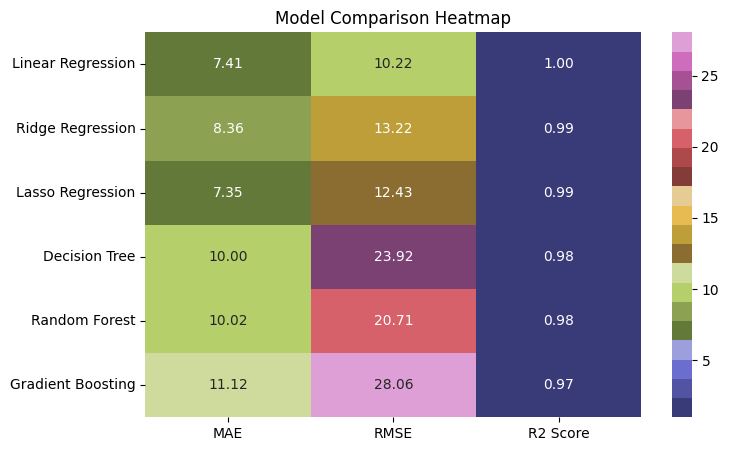

In [73]:
plt.figure(figsize=(8,5))
sns.heatmap(
    results_df[['MAE', 'RMSE', 'R2 Score']],
    annot=True,
    cmap='tab20b',
    fmt=".2f"
)
plt.title("Model Comparison Heatmap")
plt.show()

# **Final Prediction using Ensemble**

In [74]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

rf_preds = rf.predict(scaler.transform(X))
gb_preds = gb.predict(scaler.transform(X))

df['Predicted_Monthly_Energy'] = (rf_preds + gb_preds) / 2

# **Visualizations**

1.Actual vs Predicted Energy

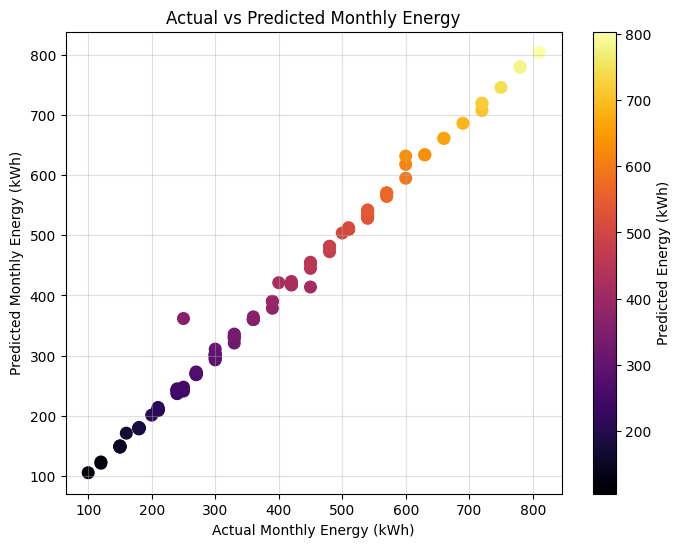

In [75]:
plt.figure(figsize=(8,6))

plt.scatter(
    y,
    df['Predicted_Monthly_Energy'],
    c=df['Predicted_Monthly_Energy'],
    cmap='inferno',
    s=70
)

plt.colorbar(label="Predicted Energy (kWh)")
plt.xlabel("Actual Monthly Energy (kWh)")
plt.ylabel("Predicted Monthly Energy (kWh)")
plt.title("Actual vs Predicted Monthly Energy")
plt.grid(True, alpha=0.4)
plt.show()

2.Energy Consumption by Consumption Level

/tmp/ipython-input-3867083211.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


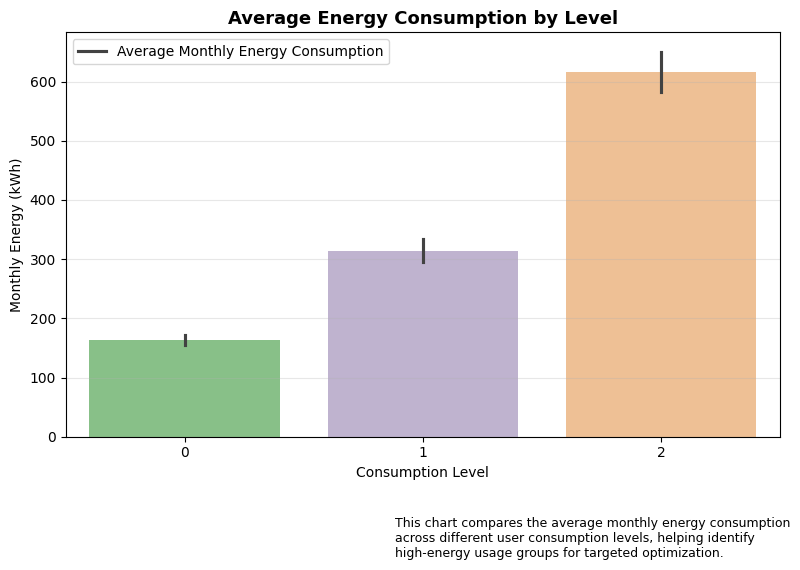

In [108]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x='consumption_level',
    y='monthly_energy_kwh',
    data=df,
    palette='Accent'
)

plt.title("Average Energy Consumption by Level", fontsize=13, fontweight='bold')
plt.xlabel("Consumption Level")
plt.ylabel("Monthly Energy (kWh)")
ax.legend(['Average Monthly Energy Consumption'])

plt.grid(axis='y', alpha=0.3)
plt.figtext(
    0.5, -0.12,
    "This chart compares the average monthly energy consumption across different user consumption levels, "
    "helping identify high-energy usage groups for targeted optimization.",
    wrap=True,
    fontsize=9
)

plt.tight_layout()
plt.show()

3.Tariff vs Energy Usage

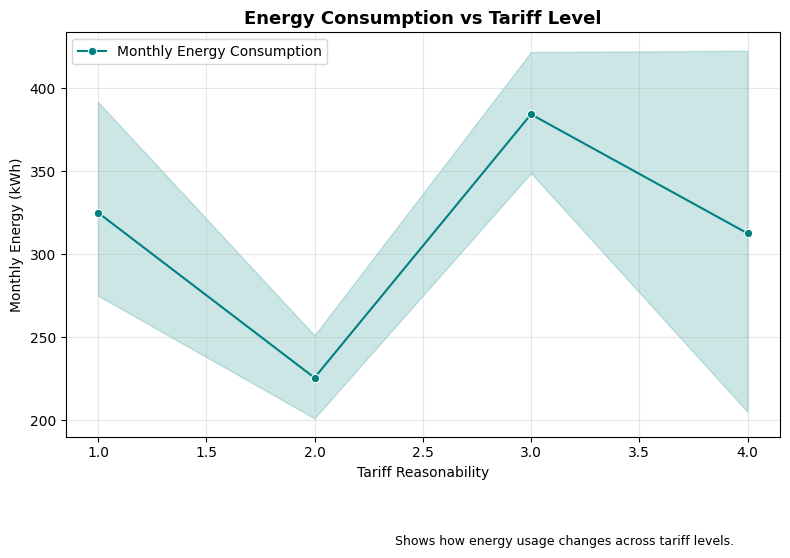

In [109]:
plt.figure(figsize=(8,5))

ax = sns.lineplot(
    x='tariff_reasonability',
    y='monthly_energy_kwh',
    data=df,
    color='teal',
    marker='o'
)

plt.title("Energy Consumption vs Tariff Level", fontsize=13, fontweight='bold')
plt.xlabel("Tariff Reasonability")
plt.ylabel("Monthly Energy (kWh)")

ax.legend(['Monthly Energy Consumption'])
plt.grid(alpha=0.3)

plt.figtext(
    0.5, -0.10,
    "Shows how energy usage changes across tariff levels.",
    fontsize=9
)

plt.tight_layout()
plt.show()

4.Correlation Analysis of Energy Usage and Cost Factors

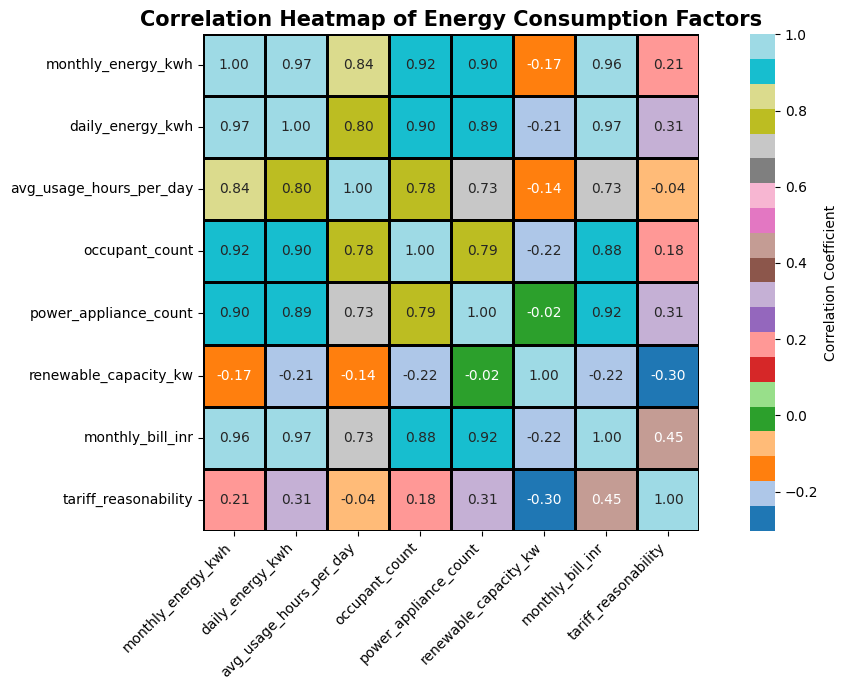

In [78]:
plt.figure(figsize=(11,7))

corr_features = [
    'monthly_energy_kwh',
    'daily_energy_kwh',
    'avg_usage_hours_per_day',
    'occupant_count',
    'power_appliance_count',
    'renewable_capacity_kw',
    'monthly_bill_inr',
    'tariff_reasonability'
]

corr_matrix = df[corr_features].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='tab20',
    fmt=".2f",
    linewidths=0.8,
    linecolor='black',
    square=True,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title(
    "Correlation Heatmap of Energy Consumption Factors",
    fontsize=15,
    fontweight='bold'
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# **Renewable Energy Recommendation**

In [79]:
def recommend_energy(row):
    energy = row['Predicted_Monthly_Energy']
    bill = row['monthly_bill_inr']

    if energy > 500:
        return {
            "Recommendation": "Hybrid (Solar + Grid)",
            "Confidence_Level": "High",
            "Estimated_Cost_Saving_INR": round(bill * 0.35, 0)
        }

    elif energy > 300:
        return {
            "Recommendation": "Solar Panels",
            "Confidence_Level": "High",
            "Estimated_Cost_Saving_INR": round(bill * 0.25, 0)
        }

    elif row['location_type'] == 1:
        return {
            "Recommendation": "Solar / Wind Energy",
            "Confidence_Level": "Medium",
            "Estimated_Cost_Saving_INR": round(bill * 0.15, 0)
        }

    else:
        return {
            "Recommendation": "Grid with Solar Backup",
            "Confidence_Level": "Medium",
            "Estimated_Cost_Saving_INR": round(bill * 0.10, 0)
        }

In [80]:
rec_df = df.apply(recommend_energy, axis=1, result_type='expand')

df['Energy_Recommendation'] = rec_df['Recommendation']
df['Confidence_Level'] = rec_df['Confidence_Level']
df['Estimated_Cost_Saving_INR'] = rec_df['Estimated_Cost_Saving_INR']

Renewable Energy Recommendation Distribution

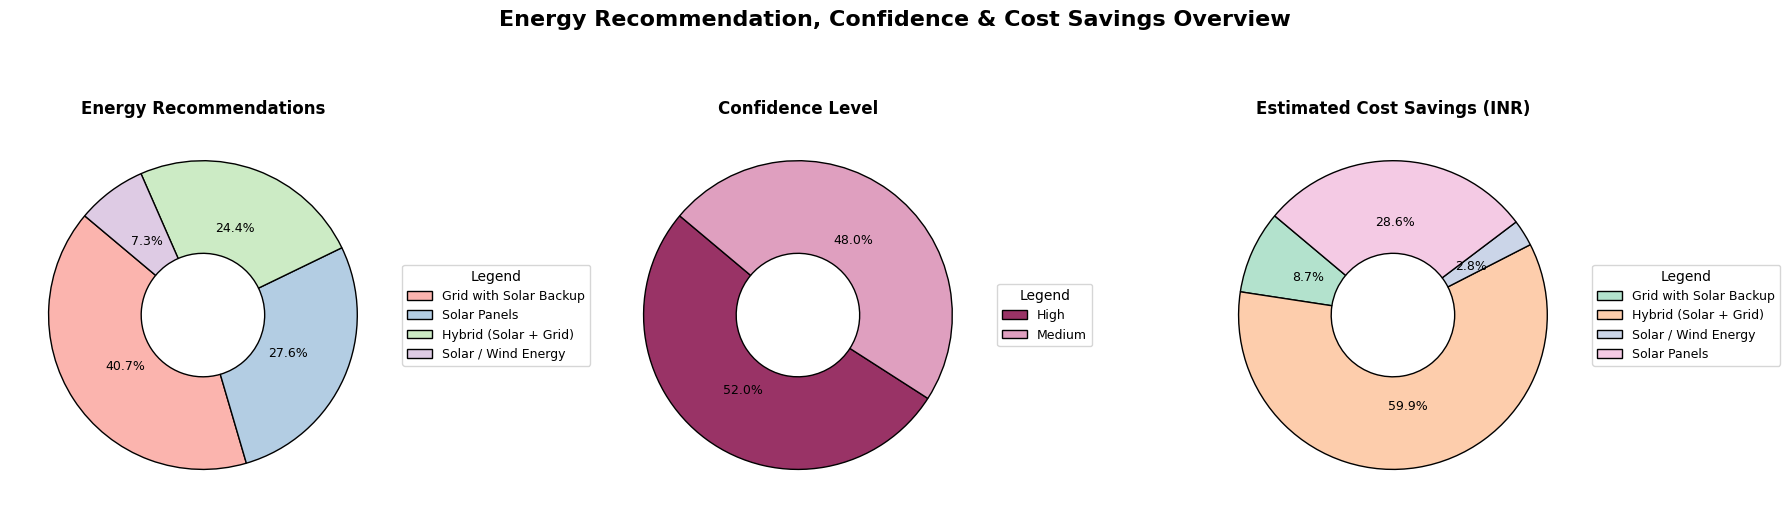

In [102]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

data_sets = [
    (
        df['Energy_Recommendation'].value_counts(),
        "Energy Recommendations",
        sns.color_palette('Pastel1')
    ),
    (
        df['Confidence_Level'].value_counts(),
        "Confidence Level",
        ['#993366', '#df9fbf']
    ),
    (
        df.groupby('Energy_Recommendation')['Estimated_Cost_Saving_INR'].sum(),
        "Estimated Cost Savings (INR)",
        sns.color_palette('Pastel2')
    )
]

for ax, (data, title, colors) in zip(axes, data_sets):
    wedges, texts, autotexts = ax.pie(
        data,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        wedgeprops={'edgecolor': 'black', 'width': 0.60},
        textprops={'fontsize': 9}
    )

    ax.legend(
        wedges,
        data.index,
        title="Legend",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        fontsize=9
    )

    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle(
    "Energy Recommendation, Confidence & Cost Savings Overview",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [82]:
df[
    [
        'monthly_energy_kwh',
        'Predicted_Monthly_Energy',
        'Energy_Recommendation',
        'Confidence_Level',
        'Estimated_Cost_Saving_INR'
    ]
].head()

,monthly_energy_kwh,Predicted_Monthly_Energy,Energy_Recommendation,Confidence_Level,Estimated_Cost_Saving_INR
0,250,361.700673,Solar Panels,High,75.0
1,300,298.302181,Grid with Solar Backup,Medium,60.0
2,450,413.986955,Solar Panels,High,225.0
3,400,421.139281,Solar Panels,High,225.0
4,250,241.221993,Grid with Solar Backup,Medium,60.0


Total Cost Savings KPI

In [103]:
total_savings = df['Estimated_Cost_Saving_INR'].sum()
avg_savings = df['Estimated_Cost_Saving_INR'].mean()
high_confidence_pct = (
    (df['Confidence_Level'] == 'High').mean() * 100
)

total_savings, avg_savings, high_confidence_pct
print(f"Total Estimated Cost Savings (INR): ₹{total_savings:,.0f}")
print(f"Average Savings per User (INR): ₹{avg_savings:,.0f}")
print(f"High Confidence Recommendations (%): {high_confidence_pct:.1f}%")

Total Estimated Cost Savings (INR): ₹53,156
Average Savings per User (INR): ₹432
High Confidence Recommendations (%): 52.0%


In [110]:
df.to_csv("Final_Energy_Insights.csv", index=False)
from google.colab import files
files.download("Final_Energy_Insights.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion & Future Scope


---

> “Turning data into insight, and insight into sustainable energy decisions.”

The project successfully predicts energy consumption and provides meaningful renewable energy recommendations with confidence levels and estimated cost savings.
The ensemble model improved prediction accuracy and enabled better decision-making.


Future enhancements may include:
- Carbon emission reduction estimation
- Deployment as a web or dashboard application
- Advanced optimization using reinforcement learning